# First tests

In [1]:
import torch
import torchvision
from torchvision.io import read_image
import matplotlib.pyplot as plt

from encoder import (
    MODEL_PATH,
    WEIGHTS,
    build_resnet,
    get_device,
    load_generator,
    load_model_state,
    preprocess_prediction,
    prediction_to_img,
)

/Users/antoningranados/Documents/School/Telecom/ima/APM_4IM06_TP/project.nosync/Latent-Space-Faces/venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
SEED = 0
_ = torch.manual_seed(SEED)

device = get_device()
print(device)

mps


In [3]:
G = load_generator(device)

In [4]:
resnet = build_resnet(G.w_dim).to(device)
_ = load_model_state(resnet, MODEL_PATH, device)
_ = resnet.eval()

In [5]:
def synchronize_device():
    if device.type == "mps":
        torch.mps.synchronize()
    elif device.type == "cuda":
        torch.cuda.synchronize()


def display_batch(images, size=256):
    images = images.detach()
    if images.shape[-2] > size or images.shape[-1] > size:
        y_step = max(1, images.shape[-2] // size)
        x_step = max(1, images.shape[-1] // size)
        images = images[..., ::y_step, ::x_step][..., :size, :size]
    images = ((images + 1.0) / 2.0).clamp(0.0, 1.0)
    images = images.permute(0, 2, 3, 1).contiguous()
    synchronize_device()
    return images.cpu().numpy()


def image_batch_to_numpy(images):
    return [img.permute(1, 2, 0).contiguous().numpy() for img in images]

In [6]:
N_TEST = 5

with torch.inference_mode():
    z = torch.randn([N_TEST, G.z_dim]).to(device)
    w = G.mapping(z, None)
    originals = G.synthesis(w)

    w_pred = resnet(WEIGHTS.transforms()(preprocess_prediction(originals)))
    w_pred = w_pred.unsqueeze(1).repeat([1, G.num_ws, 1])
    reconstructions = G.synthesis(w_pred)

    originals_display = display_batch(originals)
    reconstructions_display = display_batch(reconstructions)

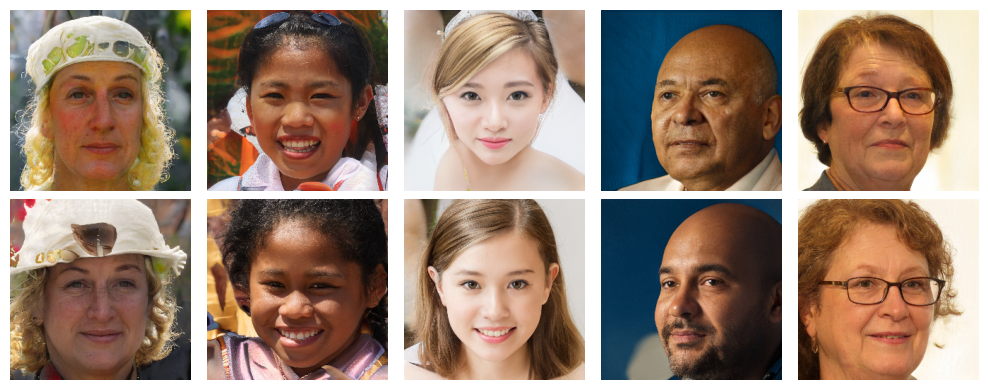

In [7]:
plt.close("all")
fig, axes = plt.subplots(2, N_TEST, figsize=(2*N_TEST, 4), squeeze=False)
for i in range(N_TEST):
    axes[0, i].imshow(originals_display[i])
    axes[1, i].imshow(reconstructions_display[i])

for ax in axes.ravel():
    ax.set_axis_off()

fig.tight_layout()
_ = plt.show()

In [8]:
test_path = [
    "./dataset/antonin.jpg",
    "./dataset/emilien.jpg",
]

with torch.inference_mode():
    imgs = [read_image(path).to(dtype=torch.float32) / 255.0 for path in test_path]
    inputs = torch.stack([WEIGHTS.transforms()(img) for img in imgs]).to(device)
    w_pred = resnet(inputs)
    w_pred = w_pred.unsqueeze(1).repeat([1, G.num_ws, 1])
    reconstructions = G.synthesis(w_pred)

    imgs_display = image_batch_to_numpy(imgs)
    reconstructions_display = display_batch(reconstructions)

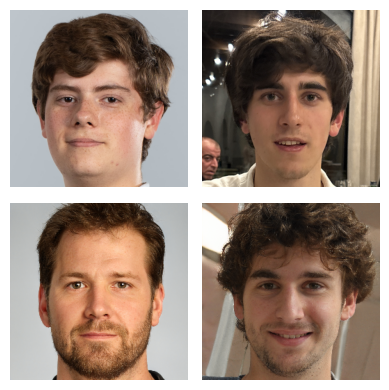

In [9]:
plt.close("all")
fig, axes = plt.subplots(2, len(test_path), figsize=(2*len(test_path), 4), squeeze=False)
for i, img in enumerate(imgs_display):
    axes[0, i].imshow(img)
    axes[1, i].imshow(reconstructions_display[i])

for ax in axes.ravel():
    ax.set_axis_off()

fig.tight_layout()
_ = plt.show()